In [ ]:
from google.colab import files
uploaded = files.upload()



Saving TrainingDataC.csv to TrainingDataC.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [ ]:
data = pd.read_csv("TrainingDataC.csv")
print(data.head())


   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   60    1   3     145   233    1        0       150     0      2.3    0   
1   35    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   55    1   1     120   236    0        1       178     0      0.8    2   
4   56    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2       1  
4    0      2       1  


In [ ]:
X = data.select_dtypes(include=['int64', 'float64'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


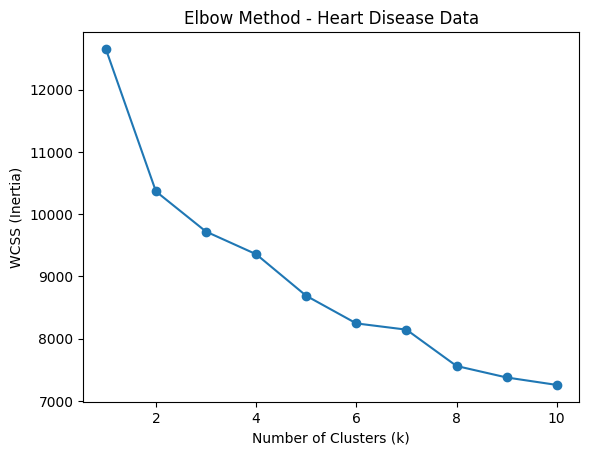

In [ ]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method - Heart Disease Data")
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score
#gotta check for shiloutte score to decide whcih k is besto besto

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette score={score:.3f}")


k=2, silhouette score=0.194
k=3, silhouette score=0.150
k=4, silhouette score=0.119
k=5, silhouette score=0.117
k=6, silhouette score=0.120
k=7, silhouette score=0.111
k=8, silhouette score=0.131
k=9, silhouette score=0.129
k=10, silhouette score=0.127


In [ ]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

print(data.head())


   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   60    1   3     145   233    1        0       150     0      2.3    0   
1   35    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   55    1   1     120   236    0        1       178     0      0.8    2   
4   56    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  output  Cluster  
0    0      1       1        0  
1    0      2       1        0  
2    0      2       1        1  
3    0      2       1        1  
4    0      2       1        1  


In [ ]:
data.to_csv("TrainingDataC.csv", index=False)

# Download file back to your system
files.download("TrainingDataC.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
data['Cluster'] = kmeans.labels_
print(data['Cluster'].value_counts())


Cluster
1    460
2    286
0    158
Name: count, dtype: int64


In [ ]:
print(kmeans.cluster_centers_)


[[ 0.12265031  0.53383763  1.21369523  0.38019718 -0.31733031  0.60410088
  -0.33886997  0.21771872 -0.24122953  0.34664659 -0.53216368 -0.17269783
   0.1447578   0.1156445 ]
 [-0.25141784 -0.36562197  0.13089343 -0.26518905  0.0023086  -0.24780347
   0.19342822  0.4383195  -0.45912213 -0.55420185  0.53813126 -0.33452147
  -0.37067766  0.6565098 ]
 [ 0.33662048  0.29314602 -0.88103086  0.21648884  0.17159522  0.06483096
  -0.12390044 -0.82526758  0.87171485  0.69986955 -0.57153327  0.63344802
   0.51622374 -1.11981237]]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(data.drop('Cluster', axis=1))


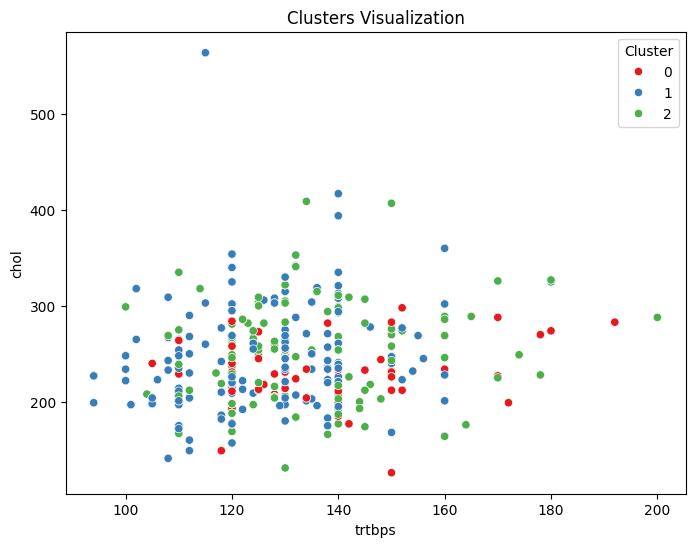

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=data['trtbps'], y=data['chol'], hue=data['Cluster'], palette='Set1')

plt.title("Clusters Visualization")
plt.show()


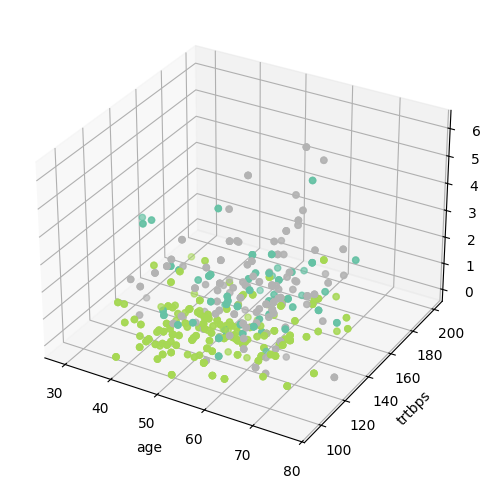

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    data['age'],
    data['trtbps'],
    data['oldpeak'],
    c=data['Cluster'],
    cmap='Set2'
)

ax.set_xlabel('age')
ax.set_ylabel('trtbps')
ax.set_zlabel('oldpeak')
plt.show()
